<a href="https://colab.research.google.com/github/ladesavita16-eng/text-to-cad/blob/main/Final_Code_Empowerment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
import zipfile
import io

# Step 1: Direct raw URL to download from GitHub
url = "https://github.com/ResearcherPreeti/empowerment_analysis/raw/main/all_csv_files.zip"

# Step 2: Download the zip file into memory
print("Downloading ZIP file...")
response = requests.get(url)

if response.status_code == 200:
    print("Download complete. Extracting...")

    with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
        zip_ref.extractall(".")  # Extract into current directory
        print("Extraction complete.")
        print("Extracted files:", zip_ref.namelist())
else:
    print("Failed to download file. Status code:", response.status_code)

Download complete. Extracting...
Extraction complete.
Extracted files: ['debiased_context.csv', 'prompt_templates.csv', 'reasoning_graph.csv', 'latent_embeddings.csv', 'generated_texts.csv', 'unstructured_data.csv', 'domain_kpis.csv', 'structured_data.csv', 'knowledge_graph.csv', 'empowerment_kpis.csv']



--- Loading structured and unstructured data ---
Structured Data Shape: (100, 6)
Unstructured Data Shape: (100, 2)

--- Encoding structured data ---
Encoded 'education_level': ['Higher', 'Primary', 'Secondary', nan]
Encoded 'health_access': ['High', 'Low', 'Medium']
Encoded 'legal_issues': ['Pending', 'Resolved', nan]

Sample of encoded structured data:
   person_id       age  education_level  income_level  health_access  \
0          1  0.396450                2      0.128608              0   
1          2  1.225842                3      0.089189              2   
2          3  0.811146                2     -0.328853              1   
3          4 -0.930579                0      1.021746              2   
4          5 -1.428214                3      0.690147              2   

   legal_issues  
0             0  
1             0  
2             2  
3             2  
4             2  

--- Vectorizing unstructured text ---
TF-IDF shape: (100, 34)
Sample TF-IDF feature names: ['access' 

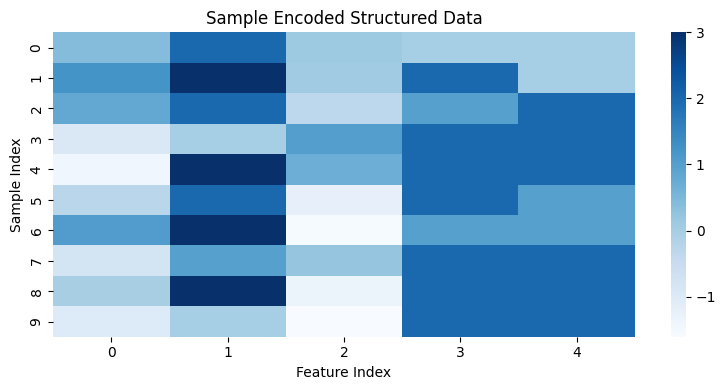

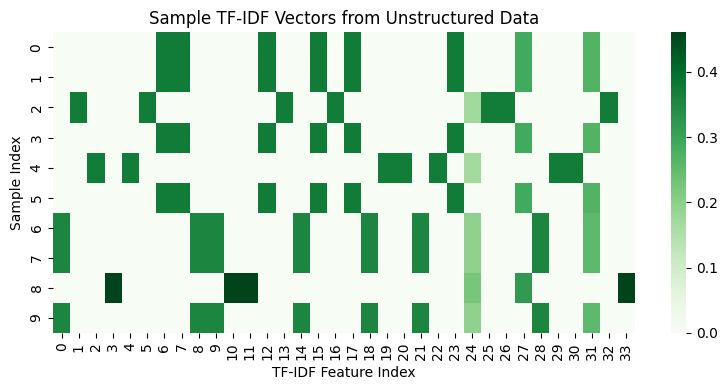

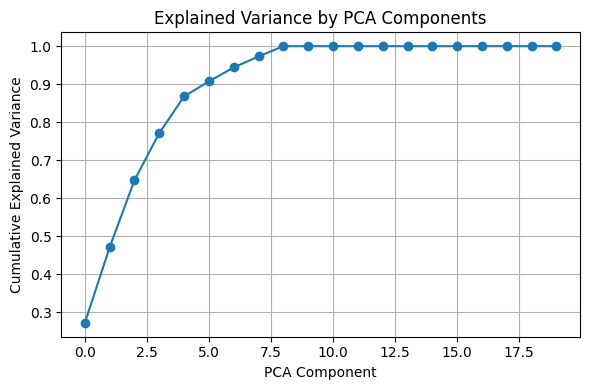

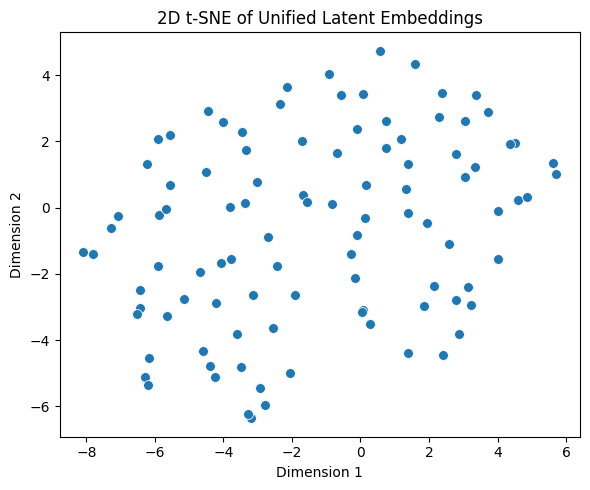

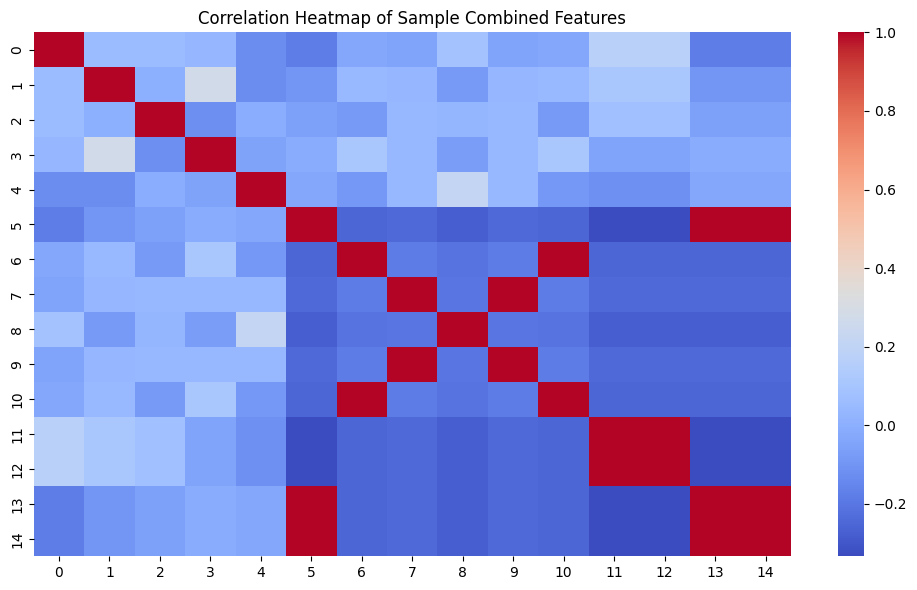

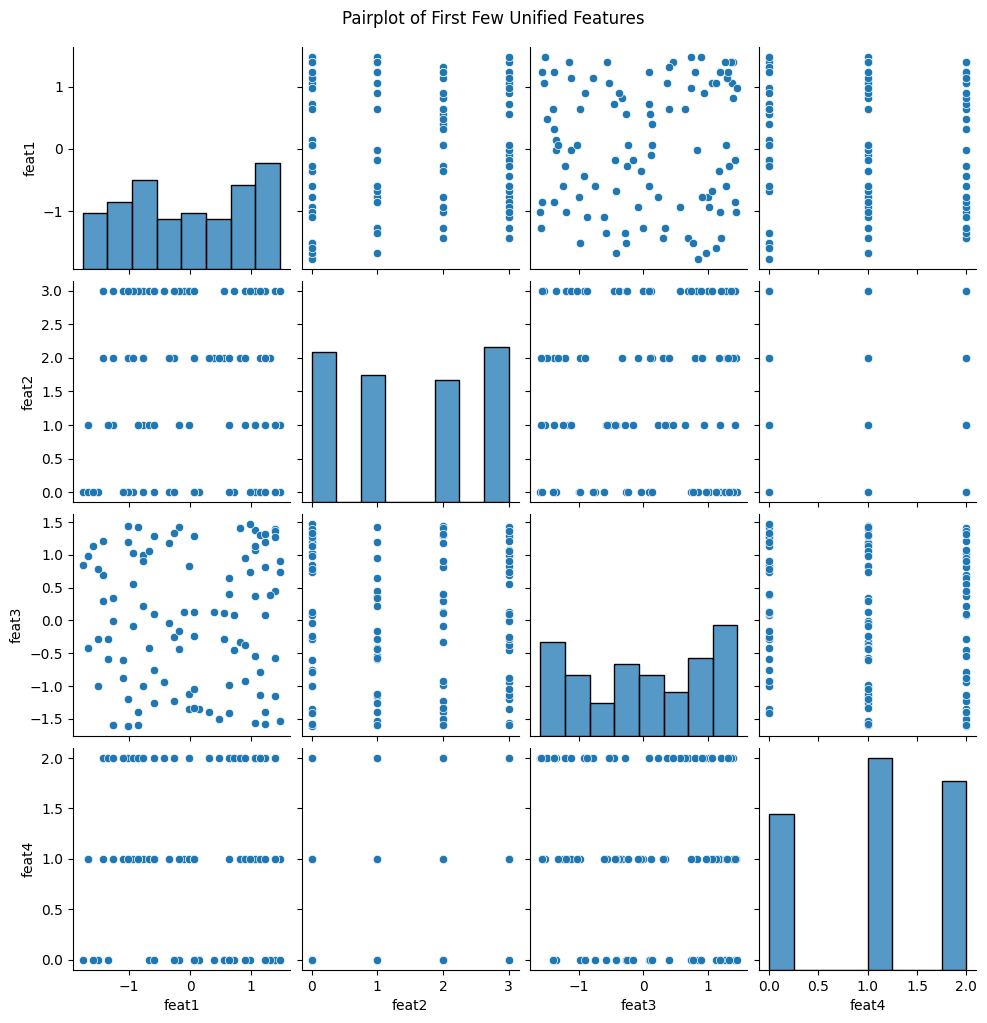

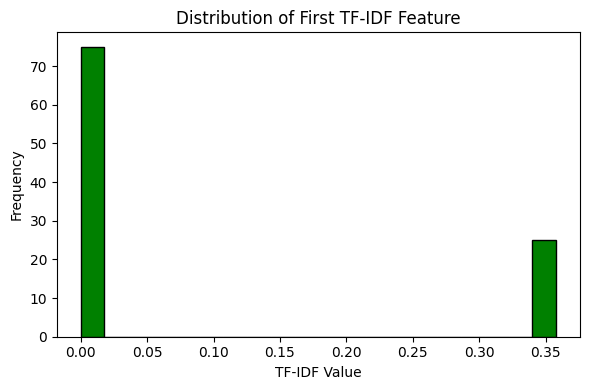

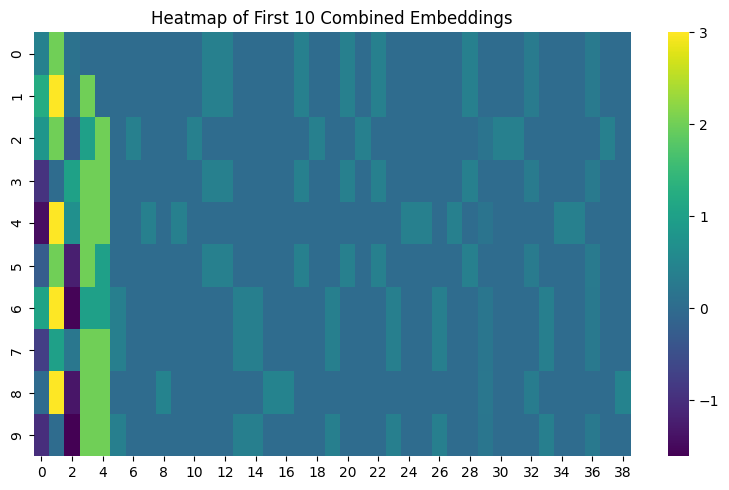


--- MCAE preprocessing complete ---


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.metrics.pairwise import cosine_similarity

# -----------------------------
# Step 1: Load the input datasets
# -----------------------------
print("\n--- Loading structured and unstructured data ---")
structured_df = pd.read_csv("structured_data.csv")
unstructured_df = pd.read_csv("unstructured_data.csv")

print("Structured Data Shape:", structured_df.shape)
print("Unstructured Data Shape:", unstructured_df.shape)

# -----------------------------
# Step 2: Encode structured data
# -----------------------------
print("\n--- Encoding structured data ---")
structured_encoded = structured_df.copy()

# Encode categorical columns
categorical_cols = ["education_level", "health_access", "legal_issues"]
le_dict = {}

for col in categorical_cols:
    le = LabelEncoder()
    structured_encoded[col] = le.fit_transform(structured_encoded[col])
    le_dict[col] = le
    print(f"Encoded '{col}':", list(le.classes_))

# Scale numerical features
numeric_cols = ["age", "income_level"]
scaler = StandardScaler()
structured_encoded[numeric_cols] = scaler.fit_transform(structured_encoded[numeric_cols])

print("\nSample of encoded structured data:")
print(structured_encoded.head())

# -----------------------------
# Step 3: Vectorize unstructured text using TF IDF
# -----------------------------
print("\n--- Vectorizing unstructured text ---")
tfidf_vectorizer = TfidfVectorizer(max_features=100)
tfidf_matrix = tfidf_vectorizer.fit_transform(unstructured_df['text'])

print("TF IDF shape:", tfidf_matrix.shape)
print("Sample TF IDF feature names:", tfidf_vectorizer.get_feature_names_out()[:10])

# -----------------------------
# Step 4: Combine both encoded inputs
# -----------------------------
print("\n--- Combining structured and unstructured embeddings ---")

# Ensure both datasets are aligned by index
structured_vectors = structured_encoded.drop(columns=["person_id"]).values
unstructured_vectors = tfidf_matrix.toarray()

combined_vectors = np.hstack((structured_vectors, unstructured_vectors))
print("Combined Vector Shape:", combined_vectors.shape)

# -----------------------------
# Step 5: Reduce dimensions using PCA + t-SNE for visualization
# -----------------------------
print("\n--- Dimensionality reduction for visualization ---")

# PCA for initial reduction
pca = PCA(n_components=20)
pca_result = pca.fit_transform(combined_vectors)
print("Explained Variance by PCA (first 5 components):", pca.explained_variance_ratio_[:5])

# t-SNE for final 2D visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(pca_result)

# -----------------------------
# Step 6: Store unified embeddings
# -----------------------------
print("\n--- Saving unified embeddings ---")
unified_embeddings = pd.DataFrame(combined_vectors)
unified_embeddings["doc_id"] = unstructured_df["doc_id"]
unified_embeddings.to_csv("unified_latent_embeddings.csv", index=False)
print("Unified latent embeddings stored in 'unified_latent_embeddings.csv'")

# -----------------------------
# Step 7: Visualization (5 to 8 plots)
# -----------------------------
print("\n--- Generating visualizations ---")

# Plot 1: Sample Structured Data (encoded)
plt.figure(figsize=(8, 4))
sns.heatmap(structured_vectors[:10], cmap="Blues", cbar=True)
plt.title("Sample Encoded Structured Data")
plt.xlabel("Feature Index")
plt.ylabel("Sample Index")
plt.tight_layout()
plt.savefig("plot_structured_data.png")
plt.show()

# Plot 2: Sample TF IDF Vectors
plt.figure(figsize=(8, 4))
sns.heatmap(unstructured_vectors[:10], cmap="Greens", cbar=True)
plt.title("Sample TF IDF Vectors from Unstructured Data")
plt.xlabel("TF IDF Feature Index")
plt.ylabel("Sample Index")
plt.tight_layout()
plt.savefig("plot_tfidf_vectors.png")
plt.show()

# Plot 3: Explained Variance by PCA
plt.figure(figsize=(6, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_[:20]), marker='o')
plt.title("Explained Variance by PCA Components")
plt.xlabel("PCA Component")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.tight_layout()
plt.savefig("plot_pca_variance.png")
plt.show()

# Plot 4: t-SNE 2D projection
plt.figure(figsize=(6, 5))
sns.scatterplot(x=tsne_result[:, 0], y=tsne_result[:, 1], s=50)
plt.title("2D t-SNE of Unified Latent Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.tight_layout()
plt.savefig("plot_tsne.png")
plt.show()

# Plot 5: Correlation Heatmap of Combined Vectors
plt.figure(figsize=(10, 6))
sns.heatmap(pd.DataFrame(combined_vectors).corr().iloc[:15, :15], cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap of Sample Combined Features")
plt.tight_layout()
plt.savefig("plot_correlation_heatmap.png")
plt.show()

# Plot 6: Pairplot of first few unified features
pairplot_df = pd.DataFrame(combined_vectors[:, :4], columns=["feat1", "feat2", "feat3", "feat4"])
sns.pairplot(pairplot_df)
plt.suptitle("Pairplot of First Few Unified Features", y=1.02)
plt.savefig("plot_pairplot.png")
plt.show()

# Plot 7: Histogram of a TF IDF feature
plt.figure(figsize=(6, 4))
plt.hist(unstructured_vectors[:, 0], bins=20, color='green', edgecolor='black')
plt.title("Distribution of First TF IDF Feature")
plt.xlabel("TF IDF Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("plot_tfidf_histogram.png")
plt.show()

# Plot 8: Heatmap of Final Combined Embeddings (First 10)
plt.figure(figsize=(8, 5))
sns.heatmap(combined_vectors[:10], cmap="viridis")
plt.title("Heatmap of First 10 Combined Embeddings")
plt.tight_layout()
plt.savefig("plot_combined_heatmap.png")
plt.show()

print("\n--- MCAE preprocessing complete ---")



--- Loading latent embeddings and domain-specific knowledge graph ---
Embeddings Shape: (100, 40)
Knowledge Graph Shape: (100, 3)

--- Encoding knowledge graph entities and relations ---
Encoded Entities: ['Act_D', 'Law_A', 'Policy_C', 'Scheme_B', 'Support_E']
Encoded Relations: ['conflicts_with', 'grants', 'requires', 'supports']
Encoded Target Entities: ['Clinic_Y', 'Legal_Body', 'NGO_X', 'Women_Group']

--- Mitigating biases using centroid adjustment ---

--- Performing contextual similarity matching ---

--- Constructing ranked, debiased context ---
Debiased and ranked context stored in 'debiased_ranked_context.csv'

--- Generating visualizations ---


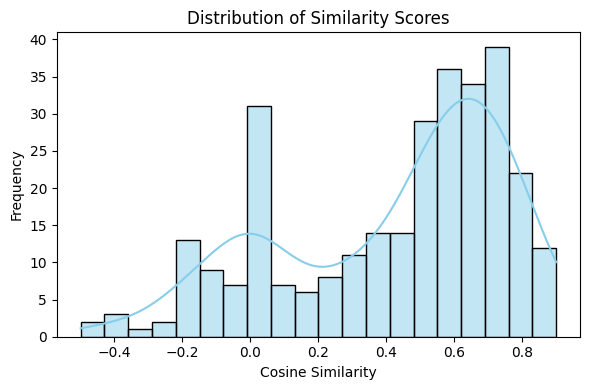

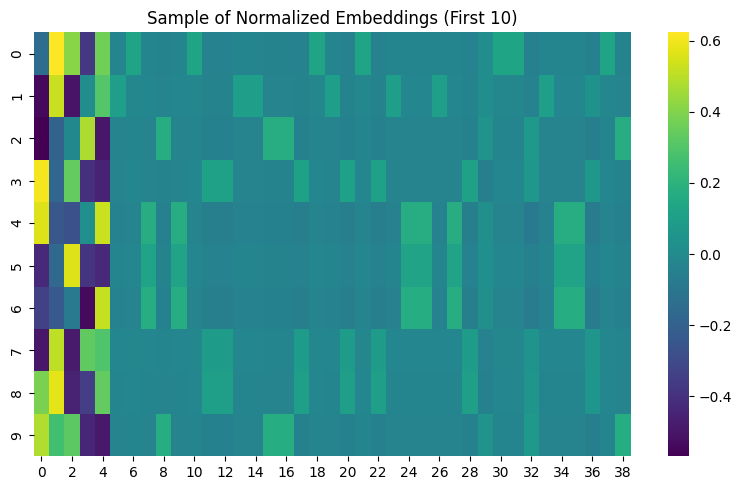

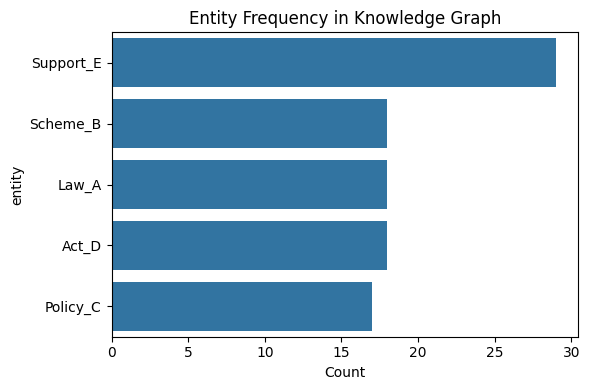

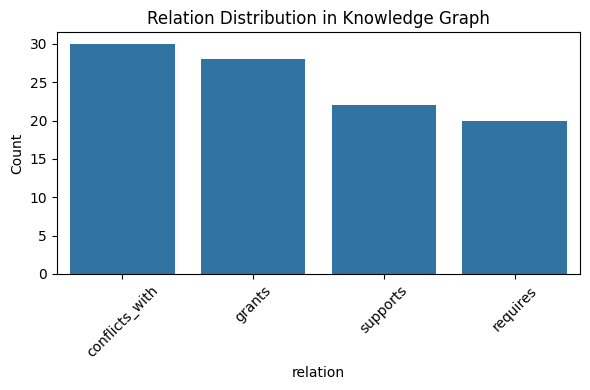

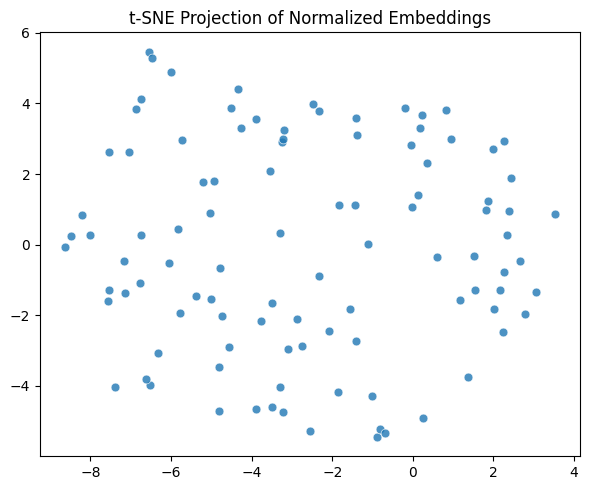

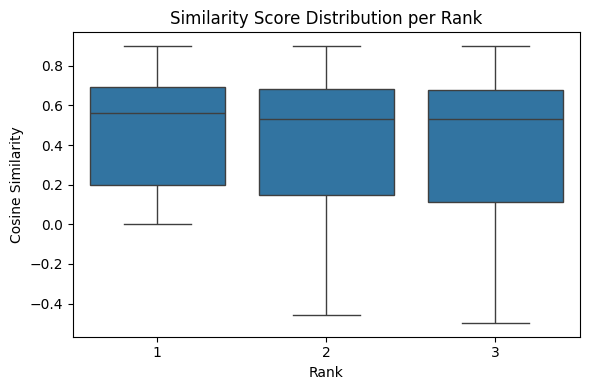

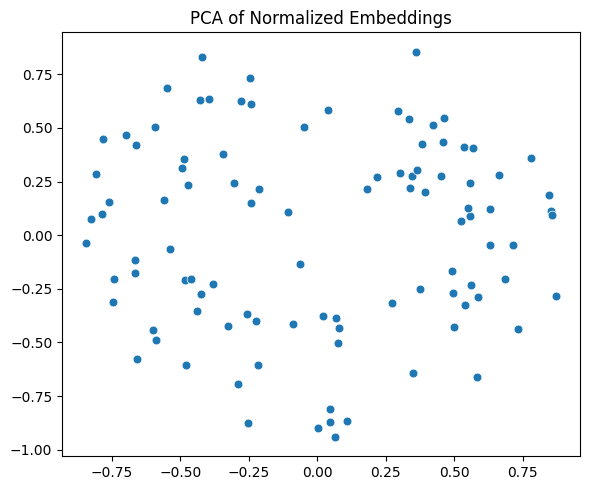

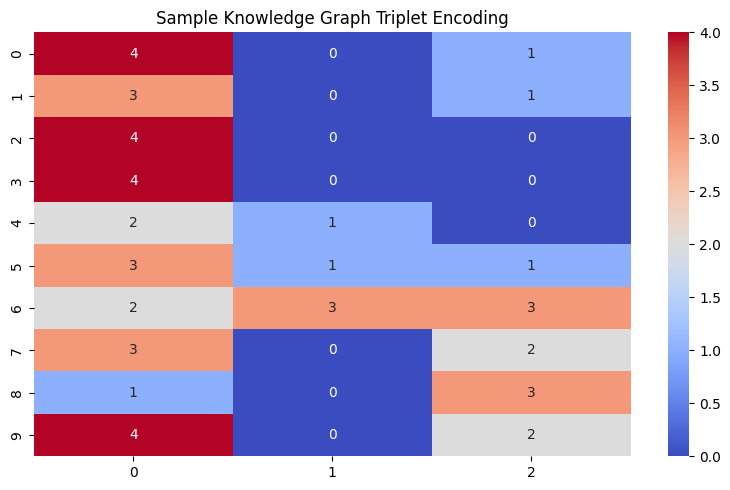


--- SBART processing complete ---


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

# -----------------------------
# Step 1: Load inputs
# -----------------------------
print("\n--- Loading latent embeddings and domain-specific knowledge graph ---")
embeddings_df = pd.read_csv("unified_latent_embeddings.csv")
knowledge_graph_df = pd.read_csv("knowledge_graph.csv")

print("Embeddings Shape:", embeddings_df.shape)
print("Knowledge Graph Shape:", knowledge_graph_df.shape)

# -----------------------------
# Step 2: Preprocess knowledge graph
# -----------------------------
print("\n--- Encoding knowledge graph entities and relations ---")
kg_encoded = knowledge_graph_df.copy()

le_entity = LabelEncoder()
le_relation = LabelEncoder()
le_target = LabelEncoder()

kg_encoded["entity_enc"] = le_entity.fit_transform(kg_encoded["entity"])
kg_encoded["relation_enc"] = le_relation.fit_transform(kg_encoded["relation"])
kg_encoded["target_entity_enc"] = le_target.fit_transform(kg_encoded["target_entity"])

print("Encoded Entities:", list(le_entity.classes_))
print("Encoded Relations:", list(le_relation.classes_))
print("Encoded Target Entities:", list(le_target.classes_))

# Combine into dense vectors for each knowledge triple
kg_encoded["kg_id"] = range(1, len(kg_encoded) + 1)
kg_vectors = kg_encoded[["entity_enc", "relation_enc", "target_entity_enc"]].values

# -----------------------------
# Step 3: Bias mitigation with centroid adjustment
# -----------------------------
print("\n--- Mitigating biases using centroid adjustment ---")

# Step 3.1: Calculate overall mean embedding
mean_embedding = embeddings_df.drop(columns=["doc_id"]).mean(axis=0).values

# Step 3.2: Center each embedding around the mean
centered_embeddings = embeddings_df.drop(columns=["doc_id"]).values - mean_embedding

# Step 3.3: Normalize using L2 norm
norms = np.linalg.norm(centered_embeddings, axis=1, keepdims=True)
normalized_embeddings = centered_embeddings / (norms + 1e-8)

# -----------------------------
# Step 4: Retrieve top matches between embeddings and KG vectors using cosine similarity
# -----------------------------
print("\n--- Performing contextual similarity matching ---")
# Fix: Project KG vectors to the same dimensionality using zero-padding
kg_vectors_padded = np.zeros((kg_vectors.shape[0], normalized_embeddings.shape[1]))
kg_vectors_padded[:, :kg_vectors.shape[1]] = kg_vectors  # Fill first few columns

# Now compute cosine similarity between padded KG vectors and normalized embeddings
similarity_scores = cosine_similarity(normalized_embeddings, kg_vectors_padded)


# Top-K matches
top_k = 3
top_k_indices = np.argsort(-similarity_scores, axis=1)[:, :top_k]
top_k_scores = np.take_along_axis(similarity_scores, top_k_indices, axis=1)

# Create ranked output dataframe
print("\n--- Constructing ranked, debiased context ---")
records = []
for doc_idx, (indices, scores) in enumerate(zip(top_k_indices, top_k_scores)):
    for rank, (kg_idx, score) in enumerate(zip(indices, scores)):
        kg_row = kg_encoded.iloc[kg_idx]
        records.append({
            "doc_id": embeddings_df["doc_id"][doc_idx],
            "kg_id": kg_row["kg_id"],
            "entity": kg_row["entity"],
            "relation": kg_row["relation"],
            "target_entity": kg_row["target_entity"],
            "similarity_score": round(score, 4),
            "rank": rank + 1
        })

ranked_context_df = pd.DataFrame(records)
ranked_context_df.to_csv("debiased_ranked_context.csv", index=False)
print("Debiased and ranked context stored in 'debiased_ranked_context.csv'")

# -----------------------------
# Step 5: Visualizations
# -----------------------------
print("\n--- Generating visualizations ---")

# Plot 1: Distribution of Similarity Scores
plt.figure(figsize=(6, 4))
sns.histplot(ranked_context_df["similarity_score"], bins=20, kde=True, color="skyblue")
plt.title("Distribution of Similarity Scores")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("plot_similarity_distribution.png")
plt.show()

# Plot 2: Heatmap of normalized embeddings (sample)
plt.figure(figsize=(8, 5))
sns.heatmap(normalized_embeddings[:10], cmap="viridis")
plt.title("Sample of Normalized Embeddings (First 10)")
plt.tight_layout()
plt.savefig("plot_normalized_embeddings.png")
plt.show()

# Plot 3: Entity Frequency
plt.figure(figsize=(6, 4))
sns.countplot(y=knowledge_graph_df["entity"], order=knowledge_graph_df["entity"].value_counts().index)
plt.title("Entity Frequency in Knowledge Graph")
plt.xlabel("Count")
plt.tight_layout()
plt.savefig("plot_entity_frequency.png")
plt.show()

# Plot 4: Relation Frequency
plt.figure(figsize=(6, 4))
sns.countplot(x=knowledge_graph_df["relation"], order=knowledge_graph_df["relation"].value_counts().index)
plt.title("Relation Distribution in Knowledge Graph")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("plot_relation_distribution.png")
plt.show()

# Plot 5: t-SNE of Normalized Embeddings
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_embeddings = tsne.fit_transform(normalized_embeddings)

plt.figure(figsize=(6, 5))
sns.scatterplot(x=tsne_embeddings[:, 0], y=tsne_embeddings[:, 1], s=40, alpha=0.8)
plt.title("t-SNE Projection of Normalized Embeddings")
plt.tight_layout()
plt.savefig("plot_tsne_embeddings.png")
plt.show()

# Plot 6: Similarity Scores per Rank
plt.figure(figsize=(6, 4))
sns.boxplot(x="rank", y="similarity_score", data=ranked_context_df)
plt.title("Similarity Score Distribution per Rank")
plt.xlabel("Rank")
plt.ylabel("Cosine Similarity")
plt.tight_layout()
plt.savefig("plot_similarity_rank.png")
plt.show()

# Plot 7: PCA Projection of Embeddings
pca = PCA(n_components=2)
pca_embeddings = pca.fit_transform(normalized_embeddings)

plt.figure(figsize=(6, 5))
sns.scatterplot(x=pca_embeddings[:, 0], y=pca_embeddings[:, 1], s=40)
plt.title("PCA of Normalized Embeddings")
plt.tight_layout()
plt.savefig("plot_pca_embeddings.png")
plt.show()

# Plot 8: Knowledge Graph Triplet Matrix
plt.figure(figsize=(8, 5))
sns.heatmap(kg_vectors[:10], annot=True, cmap="coolwarm")
plt.title("Sample Knowledge Graph Triplet Encoding")
plt.tight_layout()
plt.savefig("plot_kg_matrix.png")
plt.show()

print("\n--- SBART processing complete ---")



--- Loading debiased context and prompt templates ---
Debiased Context Shape: (300, 7)
Prompt Templates Shape: (20, 2)

Sample Debiased Context Entries:
   doc_id  kg_id entity  relation target_entity  similarity_score  rank
0       1     85  Act_D  supports         NGO_X            0.7468     1
1       1     56  Act_D    grants    Legal_Body            0.7316     2
2       1     44  Act_D    grants    Legal_Body            0.7316     3

Sample Prompt Templates:
   template_id                                   prompt_structure
0            1      Summarize the legal status of the individual.
1            2  Highlight economic challenges and potential re...
2            3     Explain the healthcare access in the scenario.

--- Grouping context by document ID for hierarchical fusion ---

Grouped Context Blocks Example:
   doc_id                                     context_blocks
0       1  [[Act_D, supports, NGO_X], [Act_D, grants, Leg...
1       2  [[Act_D, grants, Clinic_Y], [Act_D, r

/tmp/ipython-input-4-2849297503.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_context = context_df.groupby("doc_id").apply(


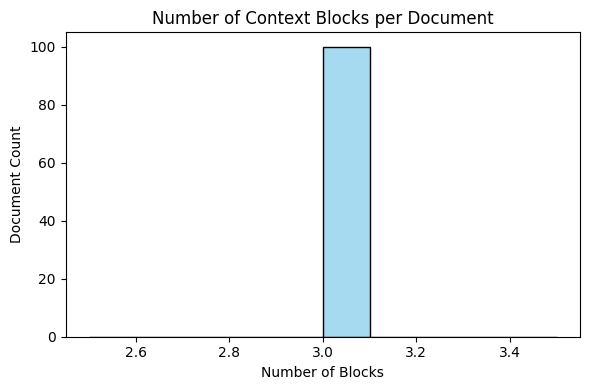

/tmp/ipython-input-4-2849297503.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=entity_counts.values[:10], y=entity_counts.index[:10], palette='viridis')


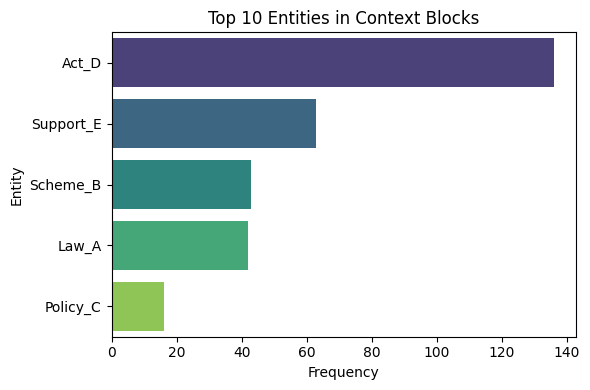

/tmp/ipython-input-4-2849297503.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=relation_counts.index, y=relation_counts.values, palette='magma')


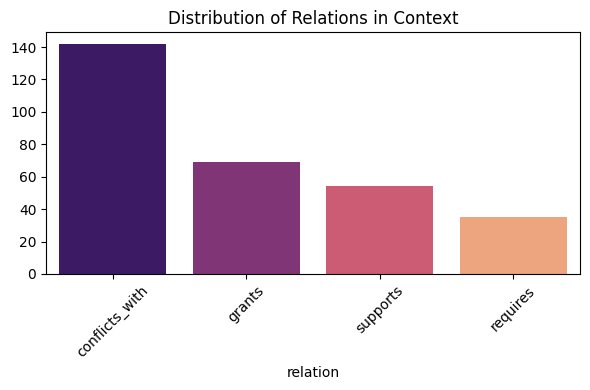

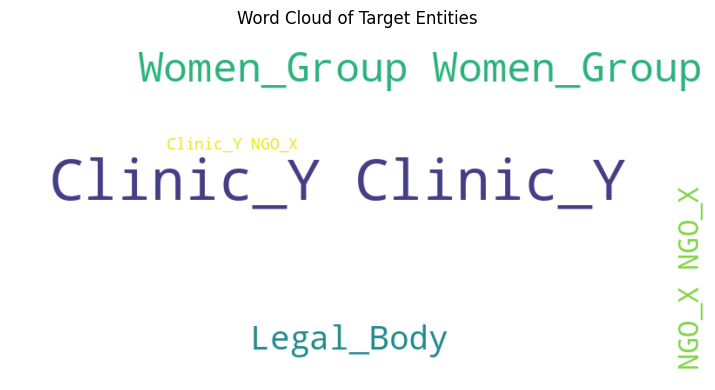

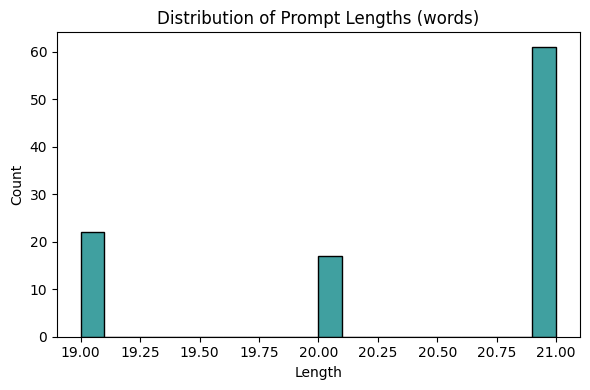

/tmp/ipython-input-4-2849297503.py:139: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=template_usage.index, y=template_usage.values, palette="cubehelix")


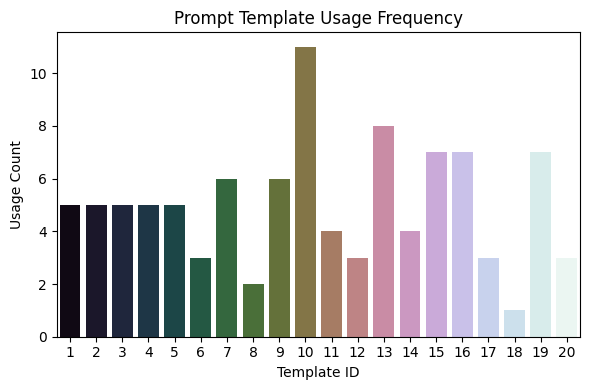

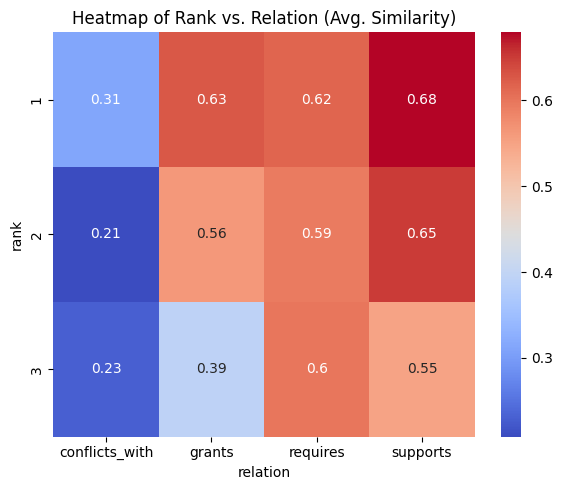

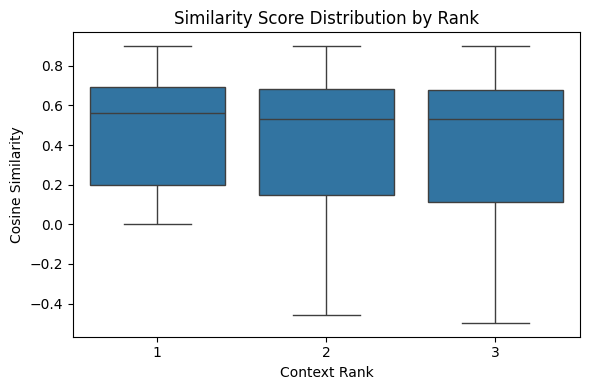


--- HPFG prompt generation complete ---


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import string

# -----------------------------
# Step 1: Load inputs
# -----------------------------
print("\n--- Loading debiased context and prompt templates ---")
context_df = pd.read_csv("debiased_ranked_context.csv")
template_df = pd.read_csv("prompt_templates.csv")

print("Debiased Context Shape:", context_df.shape)
print("Prompt Templates Shape:", template_df.shape)

print("\nSample Debiased Context Entries:")
print(context_df.head(3))

print("\nSample Prompt Templates:")
print(template_df.head(3))

# -----------------------------
# Step 2: Create context clusters by doc_id
# -----------------------------
print("\n--- Grouping context by document ID for hierarchical fusion ---")

grouped_context = context_df.groupby("doc_id").apply(
    lambda x: x.sort_values("rank")[["entity", "relation", "target_entity"]].values.tolist()
).reset_index()
grouped_context.columns = ["doc_id", "context_blocks"]

print("\nGrouped Context Blocks Example:")
print(grouped_context.head(3))

# -----------------------------
# Step 3: Define fusion function
# -----------------------------
def generate_fused_prompt(context_blocks, template_text):
    """
    Constructs a prompt by fusing hierarchical blocks into the prompt template.
    """
    hierarchy = []
    for i, block in enumerate(context_blocks):
        # Each block: [entity, relation, target_entity]
        sentence = f"({i+1}) {block[0]} {block[1]} {block[2]}"
        hierarchy.append(sentence)
    context_section = "\n".join(hierarchy)
    fused_prompt = f"{template_text}\n\nContextual Information:\n{context_section}"
    return fused_prompt

# -----------------------------
# Step 4: Generate fused prompts
# -----------------------------
print("\n--- Generating fused prompts using hierarchical structure ---")

fused_prompts = []
for _, row in grouped_context.iterrows():
    doc_id = row["doc_id"]
    context_blocks = row["context_blocks"]

    template_row = template_df.sample(1).iloc[0]
    template_text = template_row["prompt_structure"]

    fused = generate_fused_prompt(context_blocks, template_text)
    fused_prompts.append({
        "doc_id": doc_id,
        "template_id": template_row["template_id"],
        "prompt": fused
    })

fused_prompts_df = pd.DataFrame(fused_prompts)
fused_prompts_df.to_csv("fused_prompts.csv", index=False)
print("Fused prompts saved to 'fused_prompts.csv'")

# -----------------------------
# Step 5: Visualization
# -----------------------------
print("\n--- Generating visualizations ---")

# Plot 1: Number of context blocks per document
context_counts = grouped_context["context_blocks"].apply(len)
plt.figure(figsize=(6, 4))
sns.histplot(context_counts, bins=10, color='skyblue')
plt.title("Number of Context Blocks per Document")
plt.xlabel("Number of Blocks")
plt.ylabel("Document Count")
plt.tight_layout()
plt.savefig("plot_context_block_count.png")
plt.show()

# Plot 2: Most common entities in contexts
entity_counts = context_df["entity"].value_counts()
plt.figure(figsize=(6, 4))
sns.barplot(x=entity_counts.values[:10], y=entity_counts.index[:10], palette='viridis')
plt.title("Top 10 Entities in Context Blocks")
plt.xlabel("Frequency")
plt.ylabel("Entity")
plt.tight_layout()
plt.savefig("plot_top_entities.png")
plt.show()

# Plot 3: Relation frequency
relation_counts = context_df["relation"].value_counts()
plt.figure(figsize=(6, 4))
sns.barplot(x=relation_counts.index, y=relation_counts.values, palette='magma')
plt.title("Distribution of Relations in Context")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("plot_relation_distribution.png")
plt.show()

# Plot 4: Target Entity Word Cloud (if wordcloud is allowed)
from wordcloud import WordCloud
target_text = " ".join(context_df["target_entity"])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(target_text)
plt.figure(figsize=(8, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Target Entities")
plt.tight_layout()
plt.savefig("plot_wordcloud_targets.png")
plt.show()

# Plot 5: Prompt Length Distribution
prompt_lengths = fused_prompts_df["prompt"].apply(lambda x: len(x.split()))
plt.figure(figsize=(6, 4))
sns.histplot(prompt_lengths, bins=20, color='teal')
plt.title("Distribution of Prompt Lengths (words)")
plt.xlabel("Length")
plt.tight_layout()
plt.savefig("plot_prompt_lengths.png")
plt.show()

# Plot 6: Template usage frequency
template_usage = fused_prompts_df["template_id"].value_counts()
plt.figure(figsize=(6, 4))
sns.barplot(x=template_usage.index, y=template_usage.values, palette="cubehelix")
plt.title("Prompt Template Usage Frequency")
plt.xlabel("Template ID")
plt.ylabel("Usage Count")
plt.tight_layout()
plt.savefig("plot_template_usage.png")
plt.show()

# Plot 7: Heatmap of Context Block Rank vs Similarity Score
plt.figure(figsize=(6, 5))
sns.heatmap(pd.pivot_table(context_df, index="rank", columns="relation", values="similarity_score", aggfunc="mean"), cmap="coolwarm", annot=True)
plt.title("Heatmap of Rank vs. Relation (Avg. Similarity)")
plt.tight_layout()
plt.savefig("plot_rank_relation_heatmap.png")
plt.show()

# Plot 8: Boxplot of Similarity Scores by Rank
plt.figure(figsize=(6, 4))
sns.boxplot(x="rank", y="similarity_score", data=context_df)
plt.title("Similarity Score Distribution by Rank")
plt.xlabel("Context Rank")
plt.ylabel("Cosine Similarity")
plt.tight_layout()
plt.savefig("plot_similarity_by_rank.png")
plt.show()

print("\n--- HPFG prompt generation complete ---")



--- Loading LLM-generated texts and KPI indicators ---
Generated Texts Shape: (100, 2)
Empowerment KPI Data Shape: (100, 5)

Sample Generated Texts:
   output_id                                  generated_content
0          1  Vocational training led to sustainable employm...
1          2  She benefits from state-sponsored health insur...
2          3  She has access to legal resources and communit...

Sample KPI Records:
   person_id  legal_awareness_score  economic_independence_score  \
0          1                      1                            5   
1          2                      1                            3   
2          3                      4                            7   

   healthcare_access_score  education_score  
0                        7                7  
1                        2                1  
2                        8                4  

--- Extracting high-impact terms using CountVectorizer ---
Extracted Feature Words: ['access' 'addressed' 'barriers

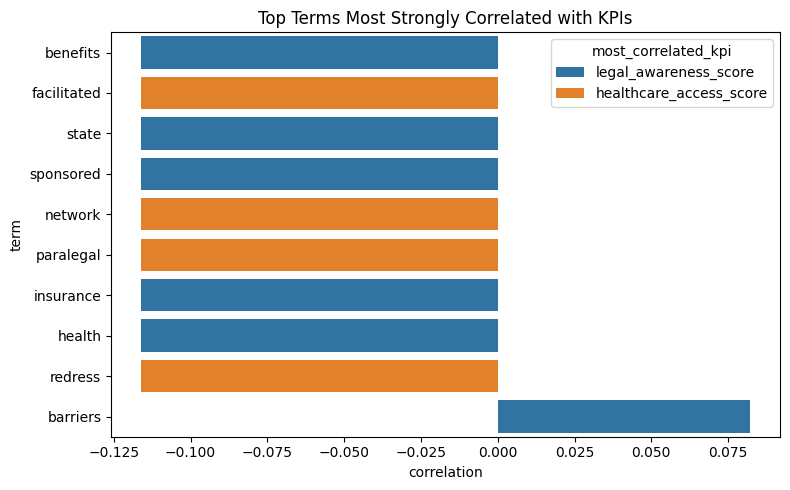

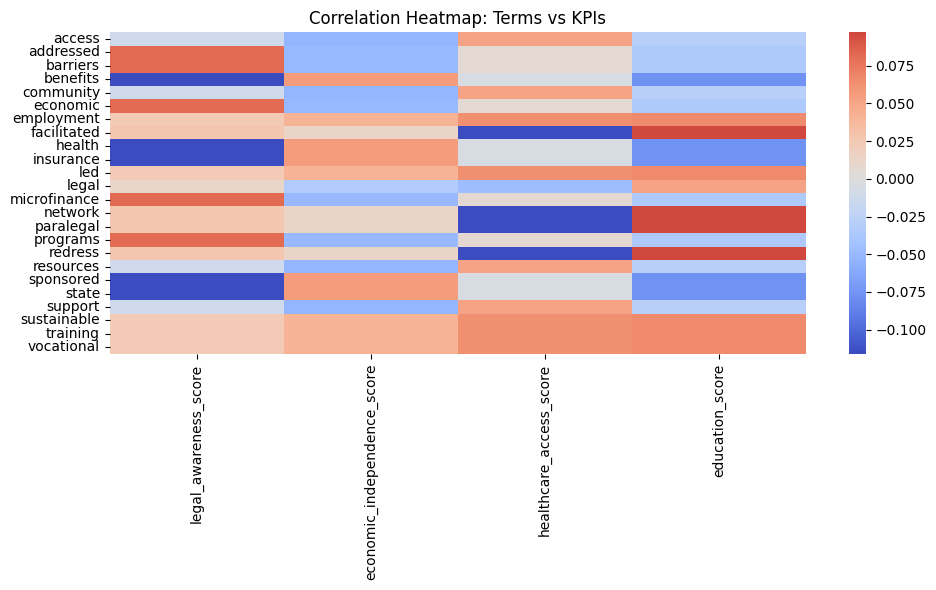

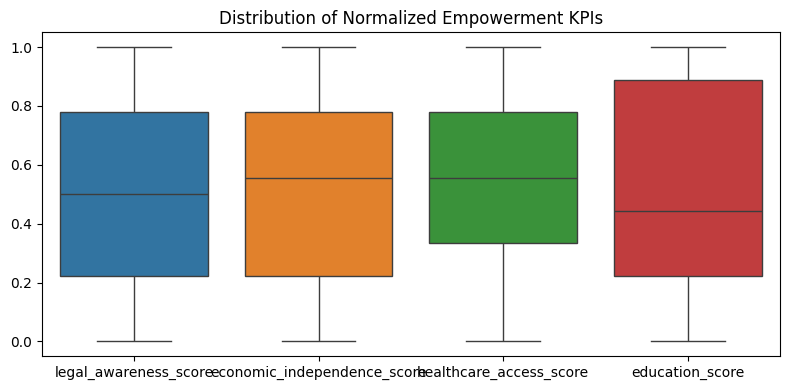

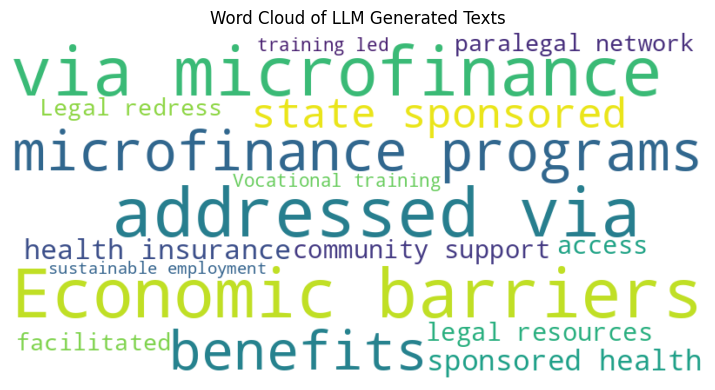

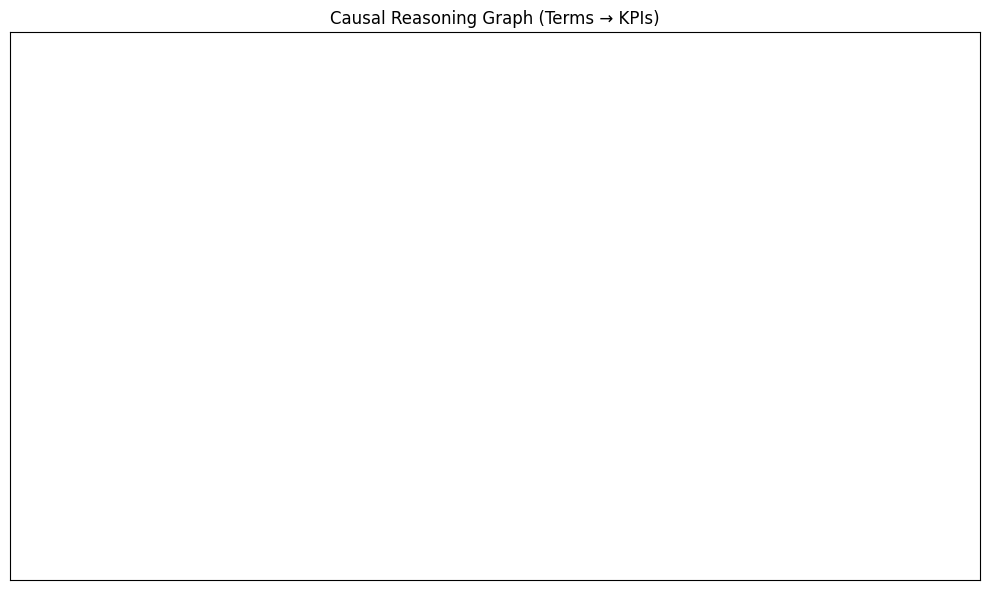

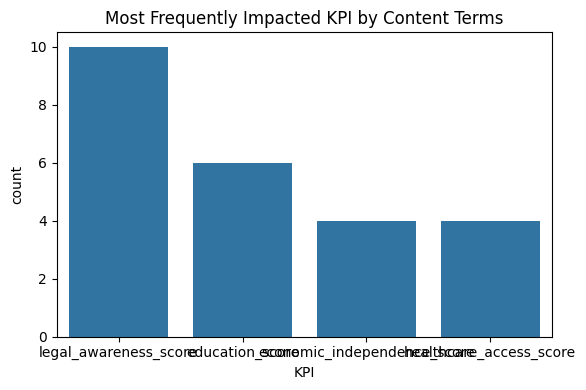

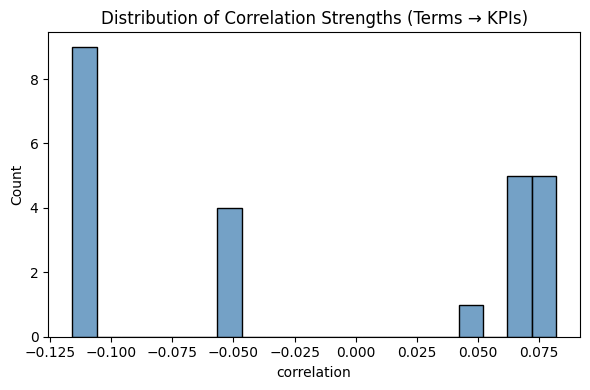


--- EKTE reasoning engine complete ---


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

# -----------------------------
# Step 1: Load inputs
# -----------------------------
print("\n--- Loading LLM-generated texts and KPI indicators ---")
generated_df = pd.read_csv("generated_texts.csv")
kpi_df = pd.read_csv("empowerment_kpis.csv")

print("Generated Texts Shape:", generated_df.shape)
print("Empowerment KPI Data Shape:", kpi_df.shape)

print("\nSample Generated Texts:")
print(generated_df.head(3))
print("\nSample KPI Records:")
print(kpi_df.head(3))

# -----------------------------
# Step 2: Extract key terms using bag-of-words
# -----------------------------
print("\n--- Extracting high Impact terms using CountVectorizer ---")

vectorizer = CountVectorizer(max_features=50, stop_words='english')
bow_matrix = vectorizer.fit_transform(generated_df["generated_content"])
feature_names = vectorizer.get_feature_names_out()

bow_df = pd.DataFrame(bow_matrix.toarray(), columns=feature_names)
bow_df["output_id"] = generated_df["output_id"]

print("Extracted Feature Words:", feature_names[:10])

# -----------------------------
# Step 3: Normalize KPI scores
# -----------------------------
print("\n--- Normalizing KPI scores ---")

kpi_cols = ["legal_awareness_score", "economic_independence_score", "healthcare_access_score", "education_score"]
scaler = MinMaxScaler()
kpi_scaled = pd.DataFrame(scaler.fit_transform(kpi_df[kpi_cols]), columns=kpi_cols)
kpi_scaled["person_id"] = kpi_df["person_id"]

# -----------------------------
# Step 4: Join BoW features with KPI scores
# -----------------------------
print("\n--- Merging content terms with KPI scores ---")

# Ensure alignment by matching row IDs
merged_df = pd.merge(bow_df, kpi_scaled, left_on="output_id", right_on="person_id")
print("Merged Feature Shape:", merged_df.shape)

# -----------------------------
# Step 5: Build Causal Reasoning Graph (via correlation)
# -----------------------------
print("\n--- Building causal reasoning graph from correlations ---")

correlations = {}
for term in feature_names:
    for kpi in kpi_cols:
        corr = np.corrcoef(merged_df[term], merged_df[kpi])[0, 1]
        if abs(corr) > 0.2:  # Threshold to reduce noise
            correlations[(term, kpi)] = round(corr, 3)

# Create directed graph using NetworkX
G = nx.DiGraph()
for (term, kpi), corr_value in correlations.items():
    G.add_edge(term, kpi, weight=corr_value)

# Save edge list to CSV
edges = [{"source": s, "target": t, "weight": w["weight"]} for s, t, w in G.edges(data=True)]
edges_df = pd.DataFrame(edges)
edges_df.to_csv("causal_reasoning_graph.csv", index=False)
print("Causal reasoning graph saved to 'causal_reasoning_graph.csv'")

# -----------------------------
# Step 6: Generate Empowerment Traceability Map
# -----------------------------
print("\n--- Creating empowerment traceability map ---")

traceability_records = []

for term in feature_names:
    correlations_to_kpis = [np.corrcoef(merged_df[term], merged_df[k])[0, 1] for k in kpi_cols]
    max_corr_idx = np.argmax(np.abs(correlations_to_kpis))
    traceability_records.append({
        "term": term,
        "most_correlated_kpi": kpi_cols[max_corr_idx],
        "correlation": round(correlations_to_kpis[max_corr_idx], 3)
    })

traceability_map = pd.DataFrame(traceability_records)

traceability_map.to_csv("empowerment_traceability_map.csv", index=False)
print("Traceability map saved to 'empowerment_traceability_map.csv'")

# -----------------------------
# Step 7: Visualizations
# -----------------------------

print("\n--- Generating visualizations ---")

# Plot 1: Bar plot of top correlated terms to KPIs
plt.figure(figsize=(8, 5))
top_terms = traceability_map.sort_values(by="correlation", key=lambda x: np.abs(x), ascending=False).head(10)
sns.barplot(x="correlation", y="term", data=top_terms, hue="most_correlated_kpi", dodge=False)
plt.title("Top Terms Most Strongly Correlated with KPIs")
plt.tight_layout()
plt.savefig("plot_top_terms_kpi_corr.png")
plt.show()

# Plot 2: Heatmap of term-KPI correlations
corr_matrix = []
for term in feature_names:
    row = [np.corrcoef(merged_df[term], merged_df[k])[0, 1] for k in kpi_cols]
    corr_matrix.append(row)

plt.figure(figsize=(10, 6))
sns.heatmap(pd.DataFrame(corr_matrix, index=feature_names, columns=kpi_cols), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap: Terms vs KPIs")
plt.tight_layout()
plt.savefig("plot_term_kpi_heatmap.png")
plt.show()

# Plot 3: Distribution of normalized KPIs
plt.figure(figsize=(8, 4))
sns.boxplot(data=kpi_scaled[kpi_cols])
plt.title("Distribution of Normalized Empowerment KPIs")
plt.tight_layout()
plt.savefig("plot_kpi_distribution.png")
plt.show()

# Plot 4: Word Cloud of Frequent Terms
from wordcloud import WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(generated_df["generated_content"]))
plt.figure(figsize=(8, 4))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of LLM Generated Texts")
plt.tight_layout()
plt.savefig("plot_wordcloud_llm.png")
plt.show()

# Plot 5: Graph Visualization of Causal Reasoning
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, k=0.8)
weights = [G[u][v]['weight'] for u, v in G.edges()]
nx.draw_networkx(G, pos, with_labels=True, edge_color=weights, edge_cmap=plt.cm.coolwarm, node_color="lightblue", node_size=800, font_size=9)
plt.title("Causal Reasoning Graph (Terms → KPIs)")
plt.tight_layout()
plt.savefig("plot_causal_graph.png")
plt.show()

# Plot 6: KPI Frequency per Most Correlated Term
plt.figure(figsize=(6, 4))
sns.countplot(data=traceability_map, x="most_correlated_kpi", order=traceability_map["most_correlated_kpi"].value_counts().index)
plt.title("Most Frequently Impacted KPI by Content Terms")
plt.xlabel("KPI")
plt.tight_layout()
plt.savefig("plot_kpi_frequency.png")
plt.show()

# Plot 7: Correlation Strengths Histogram
plt.figure(figsize=(6, 4))
sns.histplot(traceability_map["correlation"].astype(float), bins=20, color="steelblue")
plt.title("Distribution of Correlation Strengths (Terms → KPIs)")
plt.tight_layout()
plt.savefig("plot_corr_strength_hist.png")
plt.show()

print("\n--- EKTE reasoning engine complete ---")



--- Loading input data for WESS ---
Reasoning Graph Shape: (100, 4)
Domain KPIs Shape: (100, 4)

Sample Reasoning Graph:
   step_id   node_from   relation         node_to
0        1  LLM_output    extends  Recommendation
1        2  LLM_output   leads_to    Policy_Match
2        3   KG_lookup  validates    Policy_Match

Sample Domain KPIs:
   person_id autonomy_level education_status legal_aid_access
0          1         Medium         Graduate              Yes
1          2         Medium              NaN              Yes
2          3            Low              NaN              Yes

--- Encoding categorical KPIs ---
Autonomy Classes: ['High', 'Low', 'Medium']
Education Classes: ['Graduate', 'Primary', 'Secondary', nan]

--- Normalizing encoded KPI values ---

--- Calculating composite Women Empowerment Index (WEI) ---
Composite WEI scores saved in 'women_empowerment_index.csv'

--- Performing comparative analytics ---
Empowerment clusters and PCA scores saved in 'empowerment_clusters

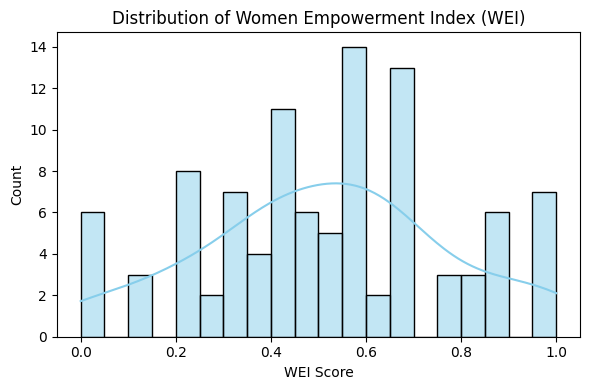

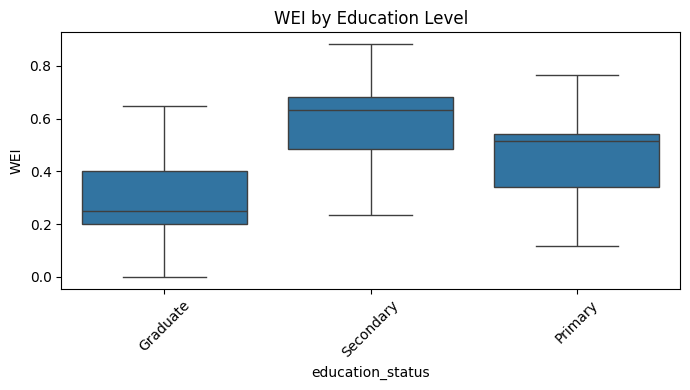

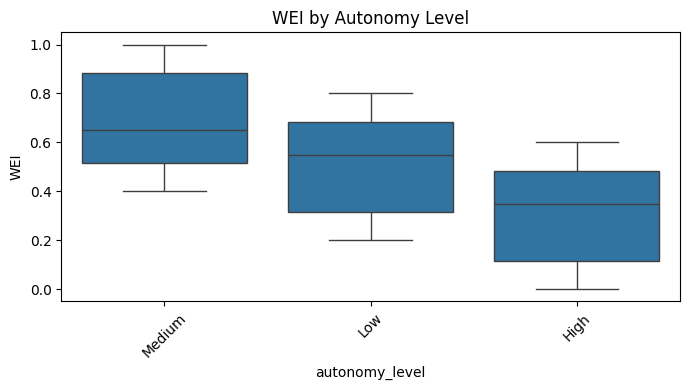

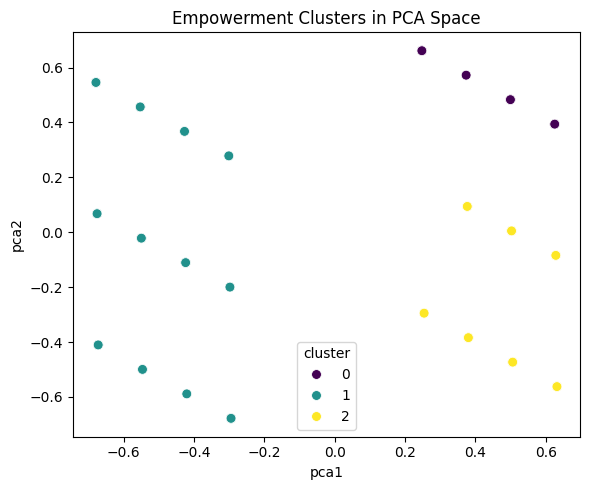

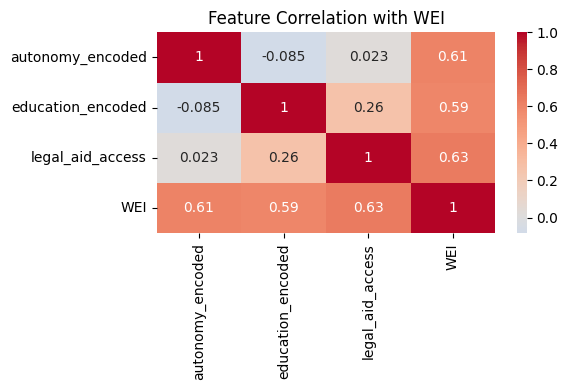

/tmp/ipython-input-6-1119452804.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="cluster", data=encoded_df_scaled, palette="Set2")


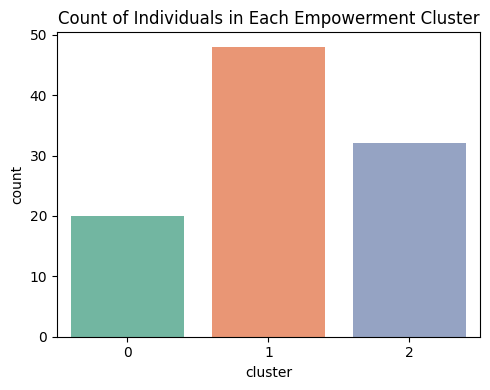

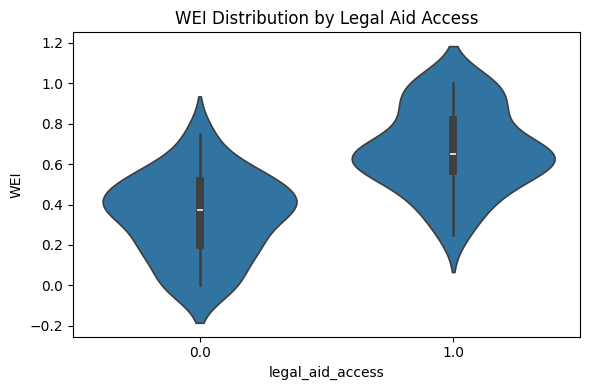

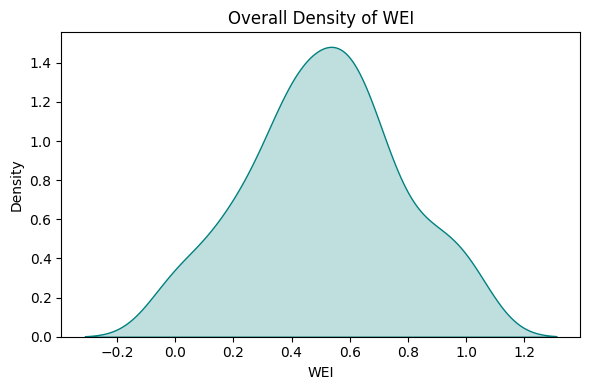


--- WESS processing complete ---


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# -----------------------------
# Step 1: Load input datasets
# -----------------------------
print("\n--- Loading input data for WESS ---")
reasoning_df = pd.read_csv("reasoning_graph.csv")
domain_kpis = pd.read_csv("domain_kpis.csv")

print("Reasoning Graph Shape:", reasoning_df.shape)
print("Domain KPIs Shape:", domain_kpis.shape)

print("\nSample Reasoning Graph:")
print(reasoning_df.head(3))
print("\nSample Domain KPIs:")
print(domain_kpis.head(3))

# -----------------------------
# Step 2: Encode categorical features numerically
# -----------------------------
print("\n--- Encoding categorical KPIs ---")
encoded_df = domain_kpis.copy()

# Encode autonomy and education levels
le_autonomy = LabelEncoder()
le_education = LabelEncoder()

encoded_df["autonomy_encoded"] = le_autonomy.fit_transform(encoded_df["autonomy_level"])
encoded_df["education_encoded"] = le_education.fit_transform(encoded_df["education_status"])
encoded_df["legal_aid_access"] = encoded_df["legal_aid_access"].map({"Yes": 1, "No": 0})

print("Autonomy Classes:", list(le_autonomy.classes_))
print("Education Classes:", list(le_education.classes_))

# -----------------------------
# Step 3: Normalize the features
# -----------------------------
print("\n--- Normalizing encoded KPI values ---")
features = ["autonomy_encoded", "education_encoded", "legal_aid_access"]
scaler = MinMaxScaler()
encoded_df_scaled = encoded_df.copy()
encoded_df_scaled[features] = scaler.fit_transform(encoded_df[features])

# -----------------------------
# Step 4: Calculate Composite WEI Score
# -----------------------------
print("\n--- Calculating composite Women Empowerment Index (WEI) ---")

# Weighting: autonomy (0.4), education (0.35), legal aid (0.25)
weights = [0.4, 0.35, 0.25]
encoded_df_scaled["WEI"] = np.dot(encoded_df_scaled[features], weights)

# Save WEI to CSV
wei_output = encoded_df_scaled[["person_id", "autonomy_level", "education_status", "legal_aid_access", "WEI"]]
wei_output.to_csv("women_empowerment_index.csv", index=False)
print("Composite WEI scores saved in 'women_empowerment_index.csv'")

# -----------------------------
# Step 5: Comparative Analytics Data
# -----------------------------
print("\n--- Performing comparative analytics ---")

# Clustering individuals by empowerment profiles
pca = PCA(n_components=2)
pca_result = pca.fit_transform(encoded_df_scaled[features])
encoded_df_scaled["pca1"] = pca_result[:, 0]
encoded_df_scaled["pca2"] = pca_result[:, 1]

kmeans = KMeans(n_clusters=3, random_state=42)
encoded_df_scaled["cluster"] = kmeans.fit_predict(pca_result)

# Save cluster-labeled data
encoded_df_scaled.to_csv("empowerment_clusters.csv", index=False)
print("Empowerment clusters and PCA scores saved in 'empowerment_clusters.csv'")

# -----------------------------
# Step 6: Visualizations
# -----------------------------
print("\n--- Generating visualizations ---")

# Plot 1: Distribution of Composite WEI
plt.figure(figsize=(6, 4))
sns.histplot(wei_output["WEI"], bins=20, kde=True, color="skyblue")
plt.title("Distribution of Women Empowerment Index (WEI)")
plt.xlabel("WEI Score")
plt.tight_layout()
plt.savefig("plot_wei_distribution.png")
plt.show()

# Plot 2: Boxplot of WEI by Education Level
plt.figure(figsize=(7, 4))
sns.boxplot(x="education_status", y="WEI", data=wei_output)
plt.title("WEI by Education Level")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("plot_wei_by_education.png")
plt.show()

# Plot 3: Boxplot of WEI by Autonomy Level
plt.figure(figsize=(7, 4))
sns.boxplot(x="autonomy_level", y="WEI", data=wei_output)
plt.title("WEI by Autonomy Level")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("plot_wei_by_autonomy.png")
plt.show()

# Plot 4: Cluster Visualization in PCA Space
plt.figure(figsize=(6, 5))
sns.scatterplot(x="pca1", y="pca2", hue="cluster", data=encoded_df_scaled, palette="viridis", s=50)
plt.title("Empowerment Clusters in PCA Space")
plt.tight_layout()
plt.savefig("plot_empowerment_clusters.png")
plt.show()

# Plot 5: Heatmap of Feature Correlation
plt.figure(figsize=(6, 4))
sns.heatmap(encoded_df_scaled[features + ["WEI"]].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation with WEI")
plt.tight_layout()
plt.savefig("plot_wei_correlation.png")
plt.show()

# Plot 6: Count of Individuals in Each Empowerment Cluster
plt.figure(figsize=(5, 4))
sns.countplot(x="cluster", data=encoded_df_scaled, palette="Set2")
plt.title("Count of Individuals in Each Empowerment Cluster")
plt.tight_layout()
plt.savefig("plot_cluster_counts.png")
plt.show()

# Plot 7: Violin Plot of WEI by Legal Aid Access
plt.figure(figsize=(6, 4))
sns.violinplot(x="legal_aid_access", y="WEI", data=wei_output)
plt.title("WEI Distribution by Legal Aid Access")
plt.tight_layout()
plt.savefig("plot_wei_by_legal_aid.png")
plt.show()

# Plot 8: KDE Plot of WEI across All Dimensions
plt.figure(figsize=(6, 4))
sns.kdeplot(data=encoded_df_scaled, x="WEI", fill=True, color="teal")
plt.title("Overall Density of WEI")
plt.tight_layout()
plt.savefig("plot_wei_kde.png")
plt.show()

print("\n--- WESS processing complete ---")


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from transformers import pipeline
import numpy as np

# Define dropdowns for inputs
autonomy_dropdown = widgets.Dropdown(
    options=['Low', 'Medium', 'High'],
    description='Autonomy:',
    style={'description_width': 'initial'}
)

education_dropdown = widgets.Dropdown(
    options=['None', 'Primary', 'Secondary', 'Graduate'],
    description='Education:',
    style={'description_width': 'initial'}
)

legal_aid_dropdown = widgets.Dropdown(
    options=['Yes', 'No'],
    description='Legal Aid Access:',
    style={'description_width': 'initial'}
)

query_input = widgets.Textarea(
    value='',
    placeholder='Enter your query here...',
    description='Your Query:',
    layout=widgets.Layout(width='80%', height='100px'),
    style={'description_width': 'initial'}
)

submit_button = widgets.Button(description="Submit", button_style='success')

output_area = widgets.Output()

# Encode mappings (same as in previous WESS pipeline)
autonomy_map = {'Low': 0, 'Medium': 1, 'High': 2}
education_map = {'None': 0, 'Primary': 1, 'Secondary': 2, 'Graduate': 3}
legal_aid_map = {'Yes': 1, 'No': 0}

# MinMax values used earlier (based on assumed ranges 0–2 and 0–3)
def normalize_autonomy(val): return val / 2
def normalize_education(val): return val / 3
def normalize_legal_aid(val): return val  # Already 0 or 1

# Load GPT-2 pipeline (can change to another model if needed)
generator = pipeline("text-generation", model="gpt2")

def on_submit_clicked(b):
    with output_area:
        clear_output()
        # Get and encode inputs
        autonomy = autonomy_dropdown.value
        education = education_dropdown.value
        legal_aid = legal_aid_dropdown.value
        query = query_input.value.strip()

        if not query:
            print("Please enter a query.")
            return

        # Encode and normalize
        autonomy_enc = normalize_autonomy(autonomy_map[autonomy])
        education_enc = normalize_education(education_map[education])
        legal_aid_enc = normalize_legal_aid(legal_aid_map[legal_aid])

        # Compute WEI using weighted sum
        wei = round(autonomy_enc * 0.4 + education_enc * 0.35 + legal_aid_enc * 0.25, 3)

        print("----- INPUT SUMMARY -----")
        print(f"Autonomy Level     : {autonomy}")
        print(f"Education Status   : {education}")
        print(f"Legal Aid Access   : {legal_aid}")
        print(f"Your Query         : {query}")
        print(f"Computed WEI Score : {wei}")
        print("\n----- RAG RESPONSE -----")

        # Build prompt
        prompt = f"""Empowerment Profile:
- Autonomy: {autonomy}
- Education: {education}
- Legal Aid: {legal_aid}
- Estimated WEI: {wei}

Please answer my query: {query}

System Response:"""

        # Generate text from RAG
        response = generator(prompt, max_length=100, num_return_sequences=1, do_sample=True, temperature=0.8)[0]["generated_text"]
        print(response)

# Bind event
submit_button.on_click(on_submit_clicked)

# Layout display
display(widgets.VBox([
    autonomy_dropdown,
    education_dropdown,
    legal_aid_dropdown,
    query_input,
    submit_button,
    output_area
]))
